In [2]:
import pandas as pd
df = pd.read_csv('Test.csv')

In [3]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   object 
 2   Ever_Married     2577 non-null   object 
 3   Age              2627 non-null   int64  
 4   Graduated        2603 non-null   object 
 5   Profession       2589 non-null   object 
 6   Work_Experience  2358 non-null   float64
 7   Spending_Score   2627 non-null   object 
 8   Family_Size      2514 non-null   float64
 9   Var_1            2595 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 205.4+ KB


In [5]:
df['Ever_Married'].mode()

0    Yes
Name: Ever_Married, dtype: object

In [6]:
df['Ever_Married']=df['Ever_Married'].fillna('Yes')

In [7]:
df['Graduated'].mode()

0    Yes
Name: Graduated, dtype: object

In [8]:
df['Graduated'] = df['Graduated'].fillna('Yes')

In [9]:
df['Profession'].mode()

0    Artist
Name: Profession, dtype: object

In [10]:
df['Profession']=df['Profession'].fillna('Artist')

In [11]:
df['Work_Experience'].mean()

2.552586938083121

In [12]:
df['Work_Experience']=df['Work_Experience'].fillna(2.552586938083121)

In [13]:
df['Family_Size'].mean()

2.8253778838504378

In [14]:
df['Family_Size'] = df['Family_Size'].fillna(2.8253778838504378)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   object 
 2   Ever_Married     2627 non-null   object 
 3   Age              2627 non-null   int64  
 4   Graduated        2627 non-null   object 
 5   Profession       2627 non-null   object 
 6   Work_Experience  2627 non-null   float64
 7   Spending_Score   2627 non-null   object 
 8   Family_Size      2627 non-null   float64
 9   Var_1            2595 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 205.4+ KB


In [16]:
df.drop(columns=['Var_1'], inplace=True)

The column 'Var_1' was removed during preprocessing because its semantic meaning was not available and is an anonymised categorical feature, making it difficult to interpret during the clustering analysis. 

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   object 
 2   Ever_Married     2627 non-null   object 
 3   Age              2627 non-null   int64  
 4   Graduated        2627 non-null   object 
 5   Profession       2627 non-null   object 
 6   Work_Experience  2627 non-null   float64
 7   Spending_Score   2627 non-null   object 
 8   Family_Size      2627 non-null   float64
dtypes: float64(2), int64(2), object(5)
memory usage: 184.8+ KB


In [18]:
df['Spending_Score'].unique()

array(['Low', 'Average', 'High'], dtype=object)

In [19]:
df['Spending_Score_num'] = df['Spending_Score'].map({
    'Low' : 0,
    'Average' : 1,
    'High' : 2
})

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  2627 non-null   int64  
 1   Gender              2627 non-null   object 
 2   Ever_Married        2627 non-null   object 
 3   Age                 2627 non-null   int64  
 4   Graduated           2627 non-null   object 
 5   Profession          2627 non-null   object 
 6   Work_Experience     2627 non-null   float64
 7   Spending_Score      2627 non-null   object 
 8   Family_Size         2627 non-null   float64
 9   Spending_Score_num  2627 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 205.4+ KB


In [21]:
col_clust = ['Age' , 'Spending_Score_num'] 
df2 = df[col_clust].copy()

In [22]:
from sklearn.preprocessing import StandardScaler
standardiser = StandardScaler()
df2_sc = standardiser.fit_transform(df2)

In [23]:
from sklearn.cluster import KMeans
wcss = []
K = range(1,11)
for k in K:
    k_means = KMeans(n_clusters=k, random_state=0)
    k_means.fit(df2_sc)
    wcss.append(k_means.inertia_)

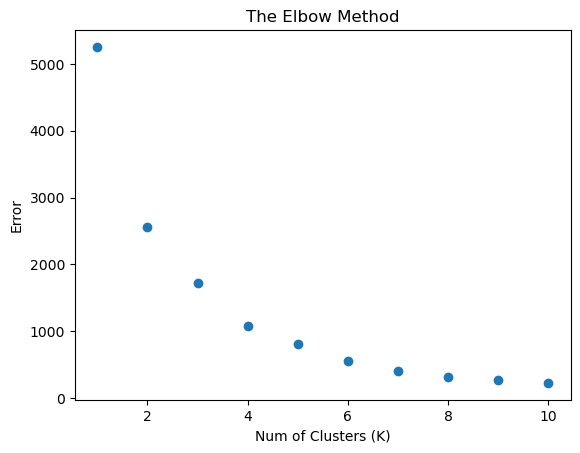

In [24]:
import matplotlib.pyplot as plt
plt.scatter(K, wcss)
plt.title('The Elbow Method')
plt.xlabel('Num of Clusters (K)')
plt.ylabel('Error')
plt.show()

I used the Elbow Method to find the best number of clusters for the clustering. I decided to split the data points into 6 clusters, since after the point at 6, the curve seems to level out and is not as steep as it was before. 

In [25]:
kmeans = KMeans(n_clusters=6, n_init=20, random_state=42)
clus_lab = kmeans.fit_predict(df2_sc)
df2_sc_df = pd.DataFrame(df2_sc, columns=col_clust)

In [26]:
df2_sc_df.head()

,Age,Spending_Score_num
0,-0.450948,-0.721759
1,-0.391999,0.635478
2,1.494372,-0.721759
3,0.904881,1.992715
4,-1.453083,-0.721759


In [27]:
df2 = df[col_clust].copy()
df2['labels'] = clus_lab
df2.head()

,Age,Spending_Score_num,labels
0,36,0,3
1,37,1,2
2,69,0,1
3,59,2,4
4,19,0,0


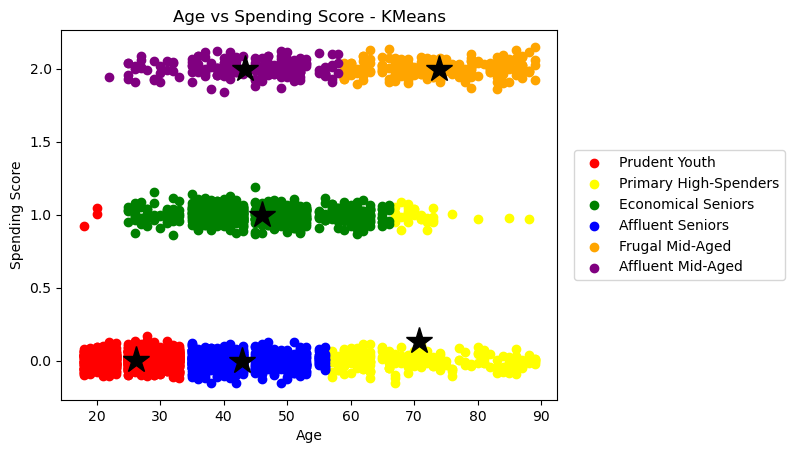

In [34]:
import numpy as np
import matplotlib.pyplot as plt

jitt = np.random.normal(0, 0.05, size=len(df2))
df2['Spending_sc_jitt'] = df2['Spending_Score_num'] + jitt

clus_1 = df2[df2['labels'] == 0]
clus_2 = df2[df2['labels'] == 1]
clus_3 = df2[df2['labels'] == 2]
clus_4 = df2[df2['labels'] == 3]
clus_5 = df2[df2['labels'] == 4]
clus_6 = df2[df2['labels'] == 5]

plt.scatter(clus_1['Age'], clus_1['Spending_sc_jitt'], label='Prudent Youth', color='red')
plt.scatter(clus_2['Age'], clus_2['Spending_sc_jitt'], label='Primary High-Spenders', color='yellow')
plt.scatter(clus_3['Age'], clus_3['Spending_sc_jitt'], label='Economical Seniors', color='green')
plt.scatter(clus_4['Age'], clus_4['Spending_sc_jitt'], label='Affluent Seniors', color='blue')
plt.scatter(clus_5['Age'], clus_5['Spending_sc_jitt'], label='Frugal Mid-Aged', color='orange')
plt.scatter(clus_6['Age'], clus_6['Spending_sc_jitt'], label='Affluent Mid-Aged', color='purple')

plt.title('Age vs Spending Score - KMeans')
plt.xlabel('Age')
plt.ylabel('Spending Score')

sc_centroids = kmeans.cluster_centers_
centr = standardiser.inverse_transform(sc_centroids)
plt.plot(centr[:, 0], centr[:, 1], 'k*', markersize=20)

plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.show()

In [36]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("Silhouette Score:", silhouette_score(df2_sc, clus_lab))
print("Davies-Bouldin Index:", davies_bouldin_score(df2_sc, clus_lab))
print("Calinski-Harabasz Index:", calinski_harabasz_score(df2_sc, clus_lab))

Silhouette Score: 0.5755526565309694
Davies-Bouldin Index: 0.5764528015165303
Calinski-Harabasz Index: 4443.970275932631


Conclusion

After analysing customer behaviour, an unsupervised learning model was developed using K-Means Clustering to segment the customer base based on Age and Spending Score. To determine an appropriate number of clusters, the Elbow Method and internal validation metrics were reviewed, and the final model was implemented with k = 6, allowing for the identification of distinct customer behaviour patterns.

Results

The model was successfully divided into 6 distinct personas based on the Age and Spending Score. 

Model Evaluation

The final model achieved the following evaluation scores:
Silhouette Score: 0.5761  
Davies-Bouldin Index: 0.5815  
Calinski-Harabasz Index: 4443.90
These results indicate a reasonably well-separated clustering structure for a simple two-feature customer segmentation model.

Identified Segments

The model identified six broad customer personas:

Prudent Youth: younger customers with low spending behaviour
Affluent Seniors: older customers with high spending behaviour
Economical Seniors: mid-to-older customers with average spending behaviour
Low-Spending Mid-Aged Customers: middle-aged customers with low spending behaviour
Frugal Older Customers: older customers with low spending behaviour
Affluent Mid-Aged Customers: younger-to-mid-aged customers with high spending behaviour

Analysis

Behavioural Trends

The strongest pattern in the data is that Spending Score acts as the primary separator, while Age provides a secondary level of segmentation within each spending tier. Customers are spread across multiple age groups, but they naturally separate into low-, average-, and high-spending bands.

Graph Interpretation

The model shows that high-value customers are not limited to one age group. Both Affluent Mid-Aged Customers and Affluent Seniors represent attractive business targets. At the same time, low-spending groups are also clearly divided by age, which suggests that businesses can tailor messaging differently for younger, middle-aged, and older budget-conscious customers.

Overall, this clustering model can support customer targeting, campaign personalisation, and audience understanding, helping a business design more focused marketing strategies for different customer types.